In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report,ConfusionMatrixDisplay
import pandas as pd
import io

# Convolutional Neural Networks

# Dataset SetUp

# Compute normalization stats

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


train_val_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

class_names = train_val_dataset.classes
print(f"Class names: {class_names}")


train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 5. Sanity check
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")  # [64, 3, 32, 32]
print(f"Label batch shape: {labels.shape}")  # [64]

100%|██████████| 170M/170M [17:18<00:00, 164kB/s]


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


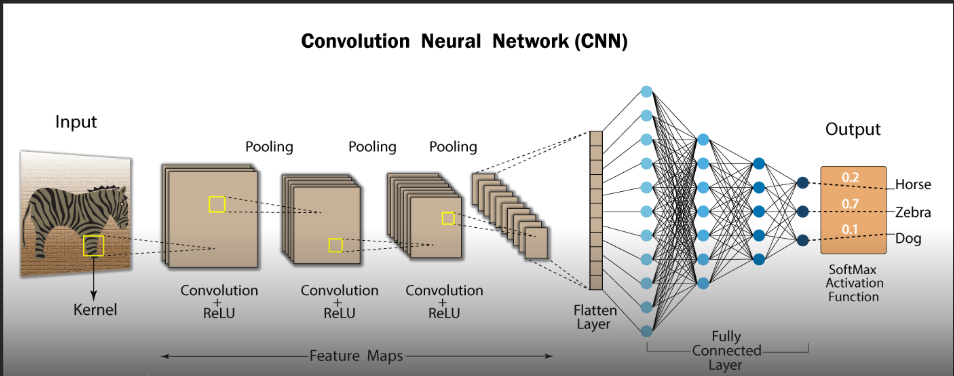


>** 1. Convolution Layer**

Think of a **filter** (also called kernel) as a small matrix (e.g., 3×3 or 5×5) that slides over the image.

At each position, it performs a **dot product** between the filter and the local patch of the image.

<img src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/no_padding_no_strides.gif" width="300">

This helps the network learn **local patterns** like:
- Edges, corners
- Textures
- Colors and gradients

> The filter learns *what to look for* — just like our eyes detect edges, motion, shapes.

>**2. Activation: ReLU**

After convolution, we apply a **non-linear activation**.

Why?
- To break linearity and let the network learn **complex patterns**.
- ReLU replaces negative values with zero:
  
  $$
  \text{ReLU}(x) = \max(0, x)
  $$

>**3. Max Pooling**

Max Pooling reduces the size of feature maps.

It keeps the **strongest activation** in each small window (like 2×2), helping with:
- Dimensionality reduction
- Translation invariance
- Faster computation

<img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/Max_pooling.png" width="300">

>**Summary**

| Component     | Purpose                                 |
|---------------|------------------------------------------|
| `Conv2d`      | Detects local patterns in image patches |
| `ReLU`        | Enables non-linear transformations      |
| `MaxPool2d`   | Reduces size, adds robustness           |
| `Linear`      | Final decision-making (classification)  |


# LeNet Architecture — The Beginning of CNNs

LeNet-5 was developed by **Yann LeCun et al. in 1998** to classify **handwritten digits** (e.g., from the MNIST dataset). It was one of the **first successful convolutional neural networks (CNNs)** and laid the foundation for modern deep learning architectures used in computer vision.

LeNet introduced **three revolutionary ideas**:

1. **Local Receptive Fields**: Just like our eyes focus on small patches of a scene, LeNet looked at **local patches** of the image using **convolutional filters**.

2. **Shared Weights**: A single filter slides across the entire image. This means:
   - Fewer parameters
   - Detects the **same pattern** (e.g., vertical edge) *anywhere* in the image

3. **Hierarchical Feature Learning**: LeNet learned **low-level patterns** (like edges) in early layers and **high-level patterns** (like shapes) in deeper layers — just like human vision!

>**Original LeNet-5 Architecture (for 32×32 grayscale inputs)**

```text
Input (32×32×1 grayscale image)
  ↓
C1: Convolution (6 filters, 5×5 kernel) → Output: 28×28×6
  ↓
S2: Average Pooling (2×2) → Output: 14×14×6
  ↓
C3: Convolution (16 filters, 5×5 kernel) → Output: 10×10×16
  ↓
S4: Average Pooling (2×2) → Output: 5×5×16
  ↓
C5: Convolution (120 filters, 5×5) → Output: 1×1×120
  ↓
Flatten → Fully Connected Layer (84 units)
  ↓
Output Layer (10 units for classification)
```
> LeNet Shape Transformations (Step-by-Step)

| Layer   | Input Shape  | Output Shape | Notes                                 |
|-------- |--------------|--------------|----------------------------------------|
| Input   | `32×32×1`    | —            | Grayscale image (MNIST-style input)    |
| Conv1   | `32×32×1`    | `28×28×6`    | 6 filters, 5×5 kernel, stride=1        |
| Pool1   | `28×28×6`    | `14×14×6`    | 2×2 **average pooling**                |
| Conv2   | `14×14×6`    | `10×10×16`   | 16 filters, 5×5 kernel, stride=1       |
| Pool2   | `10×10×16`   | `5×5×16`     | 2×2 **average pooling**                |
| Conv3   | `5×5×16`     | `1×1×120`    | 120 filters, 5×5 kernel                |
| Flatten | `1×1×120`    | `120`        | Flatten to 1D vector                   |
| FC1     | `120`        | `84`         | Fully connected layer                  |
| Output  | `84`         | `10`         | Output logits (10 classes)            |

</br>

>**Clarifications: How Do C1, C3, and C5 Work?**

**Conv1:**
- Input: `32×32×1` (grayscale)
- Kernel: `5×5`, stride 1 → Output spatial size = `32 - 5 + 1 = 28`
- 6 filters → Output: `28×28×6`

**Conv2 (sometimes labeled C3 in classic LeNet):**
- Input: `14×14×6`
- Each of the 16 filters has size `6×5×5` (depth spans all input channels)
- Output spatial size = `14 - 5 + 1 = 10`
- 16 filters → Output: `10×10×16`

**Conv3 (sometimes labeled C5):**
- Input: `5×5×16`
- Each filter has size `16×5×5` (spanning depth + full spatial region)
- Output: `1×1×120` — like a 1x1 spatial grid with 120 feature maps
- This is effectively a **fully connected layer** implemented via convolution

So, each Conv layer learns **increasingly abstract features**, while pooling reduces spatial size and increases robustness to shifts.

>**Note on Input Size**

Although MNIST images are 28×28, LeNet-5 was originally designed for **32×32 grayscale images**. The MNIST digits were **zero-padded** to 32×32 before being fed into the model. This was done to:

- Preserve edge information,
- Allow multiple convolution + pooling layers without shrinking the image too quickly.

So when we describe "original LeNet" in architectural diagrams, we usually start from 32×32 input — even if the raw MNIST data was 28×28.

> CIFAR-10 already comes as 3×32×32 RGB images, so it's a perfect fit for the adapted LeNet architecture — with adjustments for:
>- 3 channels instead of 1,
>- Slightly more filters,
>- ReLU instead of Tanh,
>- MaxPooling instead of AveragePooling.

Activation functions used were mainly Tanh, and pooling was average pooling, which differs from modern practices (ReLU and max pooling).

>**Why We Need to Modify LeNet for CIFAR-10**

CIFAR-10 is more complex than MNIST:
- Color images (3 channels),
- More object variability (10 diverse categories),
- Natural scenes instead of centered digits.

So we must adapt LeNet by:
- Changing the input channels from 1 to 3.
- Increasing the number of filters slightly to handle color and variability.
- Using ReLU activations instead of Tanh.
- Replacing average pooling with max pooling (standard in modern CNNs).

> **Adapted LeNet Architecture for CIFAR-10**

Here’s the modified architecture we'll implement:

```text
Input: 3×32×32 image
  ↓
Conv1: 3→6 filters, 5×5 kernel → ReLU → MaxPool (2×2)
  ↓
Conv2: 6→16 filters, 5×5 kernel → ReLU → MaxPool (2×2)
  ↓
Flatten
  ↓
FC1: 400 → 120 → ReLU
  ↓
FC2: 120 → 84 → ReLU
  ↓
Output: 84 → 10 (logits)
```
>Adapted LeNet for CIFAR-10 — Shape Transformations

| Layer   | Input Shape   | Output Shape | Notes                                      |
|-------- |---------------|--------------|--------------------------------------------|
| Input   | `32×32×3`     | —            | RGB image (CIFAR-10)                       |
| Conv1   | `32×32×3`     | `28×28×6`    | 6 filters, 5×5 kernel, stride=1            |
| Pool1   | `28×28×6`     | `14×14×6`    | 2×2 max pooling                            |
| Conv2   | `14×14×6`     | `10×10×16`   | 16 filters, 5×5 kernel, stride=1           |
| Pool2   | `10×10×16`    | `5×5×16`     | 2×2 max pooling                            |
| Flatten | `5×5×16`      | `400`        | Flatten 3D tensor to 1D vector             |
| FC1     | `400`         | `120`        | Fully connected, followed by ReLU          |
| FC2     | `120`         | `84`         | Fully connected, followed by ReLU          |
| Output  | `84`          | `10`         | Output logits for 10 CIFAR-10 classes      |

</br>

>This structure keeps the essence of LeNet but modernizes it for CIFAR-10. It remains relatively shallow, helping us:
- Learn CNN fundamentals,
- Train quickly,
- Establish a baseline for comparison with deeper networks.



In [4]:
class LeNet_CIFAR10(nn.Module):
    def __init__(self):
        super(LeNet_CIFAR10, self).__init__()

        # Convolutional Block
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),     # (3,32,32) → (6,28,28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                        # → (6,14,14)

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),    # → (16,10,10)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                         # → (16,5,5)
        )

        # Fully Connected Classifier
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                    # → 16*5*5 = 400
            nn.Linear(400, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)                # 10 output logits
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [5]:
CT_sample_images, _ = next(iter(train_loader))
CT_sample_images = CT_sample_images.to(device)

CT_lenet = LeNet_CIFAR10().to(device)
CT_conv_out = CT_lenet.conv_layers(CT_sample_images)  # pass through only conv_layers
print("CT_Conv output shape:", CT_conv_out.shape)

CT_Conv output shape: torch.Size([64, 16, 5, 5])


In [6]:
lenet_model = LeNet_CIFAR10().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet_model.parameters(), lr=0.001)

# For tracking metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

In [7]:
epochs = 20

for epoch in range(epochs):
    lenet_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = lenet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    lenet_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = lenet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Acc: {epoch_acc:.4f}, Val Acc: {val_correct / val_total:.4f}")

Epoch [1/20] - Train Acc: 0.3954, Val Acc: 0.4771
Epoch [2/20] - Train Acc: 0.5053, Val Acc: 0.5014
Epoch [3/20] - Train Acc: 0.5503, Val Acc: 0.5555
Epoch [4/20] - Train Acc: 0.5785, Val Acc: 0.5652
Epoch [5/20] - Train Acc: 0.5959, Val Acc: 0.5844
Epoch [6/20] - Train Acc: 0.6173, Val Acc: 0.5941
Epoch [7/20] - Train Acc: 0.6318, Val Acc: 0.5950
Epoch [8/20] - Train Acc: 0.6504, Val Acc: 0.5997
Epoch [9/20] - Train Acc: 0.6623, Val Acc: 0.6160
Epoch [10/20] - Train Acc: 0.6736, Val Acc: 0.6060
Epoch [11/20] - Train Acc: 0.6845, Val Acc: 0.6259
Epoch [12/20] - Train Acc: 0.6941, Val Acc: 0.6209
Epoch [13/20] - Train Acc: 0.7047, Val Acc: 0.6139
Epoch [14/20] - Train Acc: 0.7100, Val Acc: 0.6132
Epoch [15/20] - Train Acc: 0.7220, Val Acc: 0.6244
Epoch [16/20] - Train Acc: 0.7260, Val Acc: 0.6238
Epoch [17/20] - Train Acc: 0.7338, Val Acc: 0.6176
Epoch [18/20] - Train Acc: 0.7404, Val Acc: 0.6170
Epoch [19/20] - Train Acc: 0.7482, Val Acc: 0.6099
Epoch [20/20] - Train Acc: 0.7552, Val A

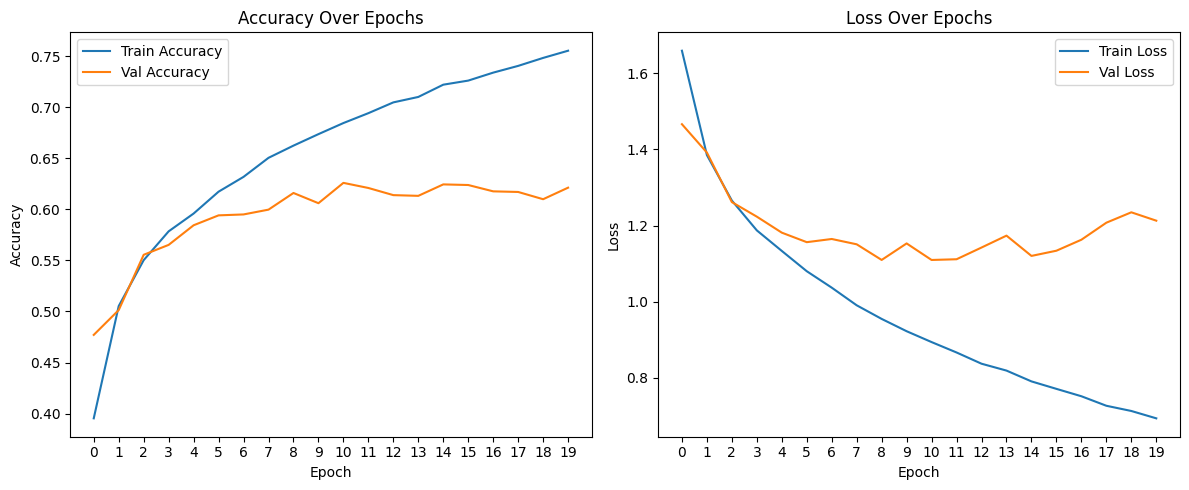

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xticks(range(epochs))
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xticks(range(epochs))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
torch.save(lenet_model.state_dict(), "lenet_cifar10.pth")

In [10]:
lenet_model_loaded = LeNet_CIFAR10().to(device)
lenet_model_loaded.load_state_dict(torch.load("lenet_cifar10.pth"))

<All keys matched successfully>

In [14]:
# Create the class for MLP model from NB03

class MLP_CIFAR10(nn.Module):
    def __init__(self, input_dim=3072, output_dim=10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, output_dim)  # output logits
        )

    def forward(self, x):
        return self.model(x)

# Load model
mlp_model = MLP_CIFAR10().to(device)
mlp_model.load_state_dict(torch.load("model_bestopt_NB03.pth"))
mlp_model.eval()

MLP_CIFAR10(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [15]:
def evaluate_model(model, dataloader, name="Model"):

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            if isinstance(model, MLP_CIFAR10):  # Only apply to MLP model
                images = images.view(images.size(0), -1)  # Flatten to [batch_size, 3072]
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"🔍 {name} | Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_preds, all_labels

In [18]:
print("Evaluating MLP Model:")
mlp_preds, mlp_labels = evaluate_model(mlp_model, test_loader, name="MLP")

print("\nEvaluating LeNet Model:")
lenet_preds, lenet_labels = evaluate_model(lenet_model, test_loader, name="LeNet")

Evaluating MLP Model:
🔍 MLP | Accuracy: 0.4251 | Macro F1: 0.4111
              precision    recall  f1-score   support

    airplane       0.39      0.59      0.47      1000
  automobile       0.46      0.59      0.52      1000
        bird       0.37      0.37      0.37      1000
         cat       0.30      0.26      0.28      1000
        deer       0.55      0.14      0.23      1000
         dog       0.39      0.29      0.33      1000
        frog       0.60      0.32      0.42      1000
       horse       0.39      0.64      0.48      1000
        ship       0.56      0.53      0.54      1000
       truck       0.43      0.52      0.47      1000

    accuracy                           0.43     10000
   macro avg       0.44      0.43      0.41     10000
weighted avg       0.44      0.43      0.41     10000


Evaluating LeNet Model:
🔍 LeNet | Accuracy: 0.6137 | Macro F1: 0.6077
              precision    recall  f1-score   support

    airplane       0.66      0.65      0.66      

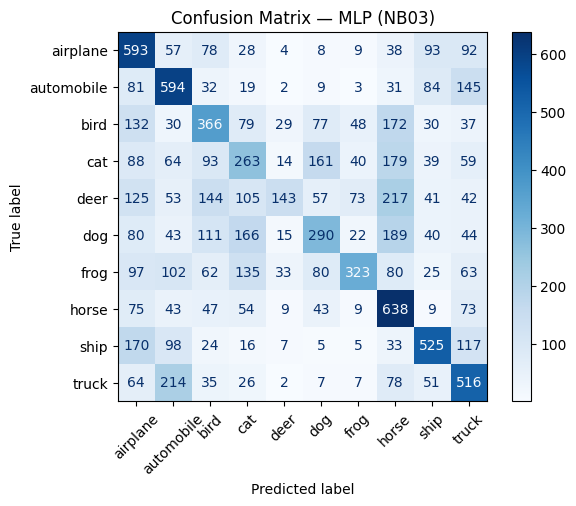

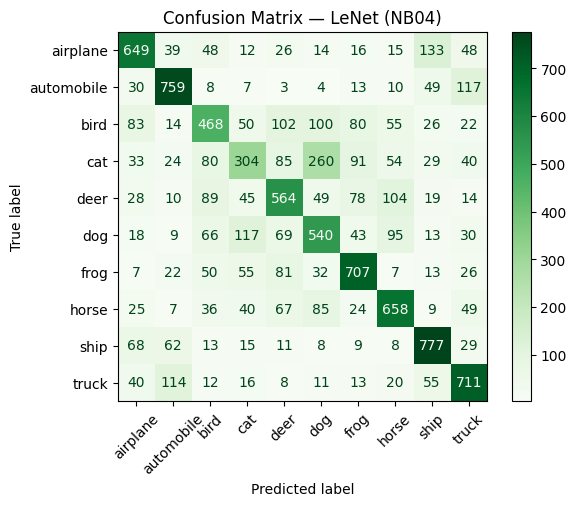

In [21]:
# MLP Confusion Matrix
cm_mlp = confusion_matrix(mlp_labels, mlp_preds)
disp_mlp = ConfusionMatrixDisplay(cm_mlp, display_labels=class_names)
disp_mlp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — MLP (NB03)")
plt.grid(False)
plt.show()

# LeNet Confusion Matrix
cm_lenet = confusion_matrix(lenet_labels, lenet_preds)
disp_lenet = ConfusionMatrixDisplay(cm_lenet, display_labels=class_names)
disp_lenet.plot(cmap='Greens', xticks_rotation=45)
plt.title("Confusion Matrix — LeNet (NB04)")
plt.grid(False)
plt.show()

>**Performance Comparison**

| Metric        | MLP (NB03) | LeNet (NB04) |
|---------------|------------|--------------|
| Accuracy      | 0.4098     | 0.6052       |
| Macro F1      | 0.3933     | 0.6034       |

LeNet significantly **outperforms the MLP** on both accuracy and F1-score. The improvement of ~20% shows how well CNNs handle spatial data compared to MLPs.


> Class-wise Insights

- **Airplane, Automobile, Frog, Ship, and Truck** were reasonably well recognized by both models.
- LeNet shows better performance on more complex or ambiguous classes like **Cat**, **Dog**, and **Bird**, which MLP struggled with.
- **F1-scores** are much more balanced in LeNet, while MLP showed large variations — a sign of overfitting to a few classes or inability to generalize spatial patterns.

> Why LeNet Performs Better

| Advantage of CNN (LeNet)        | Effect                                        |
|---------------------------------|-----------------------------------------------|
| Spatial filters (Conv layers)   | Learn edges, shapes, and textures             |
| Local connectivity              | Preserve spatial structure of image           |
| Translation invariance          | MaxPooling helps recognize objects in motion  |
| Fewer parameters                | Reduced overfitting vs. fully connected MLP   |

MLP, by contrast:
- Flattens the image, **destroying local patterns**
- Uses dense layers, resulting in **millions of parameters**
- Struggles to generalize with limited spatial awareness

LeNet’s structure is **fundamentally more suited for image data**. This exercise clearly shows the benefit of using **convolutional networks over plain MLPs** in vision tasks.

---

# AlexNet Mini – A Deeper CNN

LeNet showed us that:

- Convolutions extract spatial patterns (edges, textures).
- Pooling reduces dimensionality while keeping key features.
- Even a **shallow CNN** outperforms MLPs on image tasks.

But CIFAR-10 is **much more complex** than MNIST:

- It has **color images** (3 channels instead of 1)
- Contains **more varied categories** (e.g., airplane, dog, ship, frog)
- Includes **diverse visual patterns and backgrounds**

To handle this complexity, we need **deeper networks** that learn **hierarchical features** — from simple edges to complex object parts.

>**Enter AlexNet (2012)**

AlexNet made deep CNNs mainstream. It won the **ImageNet 2012 competition** by a huge margin and introduced:

- **More convolutional layers** for deeper abstraction  
- **Larger filter banks** to boost capacity  
- **ReLU** activations (faster training than Tanh)  
- **Dropout** for regularization  
- **GPU training** for scale


>Is LeNet Really That Shallow?

Yes — though technically it has **3 convolutional layers**, the final one (C5) acts like a **fully connected layer** (5×5 kernel on 5×5 input = 1×1 output).

So:
- It has **2 spatial convolution layers** + **1 conv-style FC layer**.
- Our **adapted LeNet** follows the same logic using PyTorch:  
  We flatten after the second pooling layer and use a dense layer instead of a 1×1 convolution.

>**Differences from LeNet**

| Feature               | LeNet (Adapted)     | AlexNet Mini            |
|-----------------------|---------------------|--------------------------|
| Input Size            | 32×32 RGB           | 32×32 RGB               |
| # Convolutional Layers| 2                   | 3                       |
| Filters per Layer     | 6 → 16              | 64 → 128 → 256          |
| Activation            | ReLU                | ReLU                    |
| Pooling               | 2×2 MaxPool         | 2×2 MaxPool             |
| Dropout               | ❌ Not used         | ✅ Yes                  |
| Output Head           | 400 → 120 → 10      | 256 → 128 → 10          |

</br>

>Why AlexNet Mini?

The original AlexNet was designed for **ImageNet** with **224×224 images** and millions of parameters. That’s **too heavy** for CIFAR-10.

So we use a **miniaturized version** of AlexNet, adapted for:

- Small image size (32×32)
- Lower memory needs
- Faster training (even on CPU/GPU)

>Architecture Summary

```text
Input (3×32×32)
↓
Conv1: 3→64, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Conv2: 64→128, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Conv3: 128→256, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Flatten
↓
Linear: 256 → 128 → ReLU → Dropout
↓
Linear: 128 → 10 → Output logits
```
**AlexNetMini Shape Transformation**

| Layer     | Input Shape     | Output Shape    | Notes                                    |
|-----------|------------------|------------------|------------------------------------------|
| Input     | `3×32×32`        | —                | RGB image                                |
| Conv1     | `3×32×32`        | `64×30×30`       | 64 filters, 3×3 kernel, stride=1         |
| MaxPool1  | `64×30×30`       | `64×15×15`       | 2×2 max pooling, stride=2                |
| Conv2     | `64×15×15`       | `128×13×13`      | 128 filters, 3×3 kernel, stride=1        |
| MaxPool2  | `128×13×13`      | `128×6×6`        | 2×2 max pooling, stride=2                |
| Conv3     | `128×6×6`        | `256×4×4`        | 256 filters, 3×3 kernel, stride=1        |
| MaxPool3  | `256×4×4`        | `256×2×2`        | 2×2 max pooling, stride=2                |
| Flatten   | `256×2×2`        | `1024`           | Flatten to vector (256×2×2 = 1024)       |
| Linear1   | `1024`           | `128`            | Fully connected layer → ReLU → Dropout   |
| Output    | `128`            | `10`             | Output logits for 10 classes             |

</br>

In [22]:
class AlexNetMini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # [B, 3, 32, 32] → [B, 64, 32, 32]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # [B, 64, 32, 32] → [B, 64, 16, 16]

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [B, 64, 16, 16] → [B, 128, 16, 16]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # → [B, 128, 8, 8]

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # → [B, 256, 8, 8]
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # → [B, 256, 8, 8]
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # → [B, 256, 8, 8]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → [B, 256, 4, 4]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten: [B, 256, 4, 4] → [B, 4096]
        x = self.classifier(x)
        return x

# Instantiate model
alexnet_model = AlexNetMini().to(device)
print(alexnet_model)

AlexNetMini(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bia

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


alexnet_model = AlexNetMini().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet_model.parameters(), lr=0.001)

epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    # Training Phase
    alexnet_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = alexnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation Phase
    alexnet_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = alexnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] - "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_correct / val_total:.4f}")

Epoch [1/20] - Train Acc: 0.3846, Val Acc: 0.5213
Epoch [2/20] - Train Acc: 0.5601, Val Acc: 0.6182
Epoch [3/20] - Train Acc: 0.6362, Val Acc: 0.6674
Epoch [4/20] - Train Acc: 0.6833, Val Acc: 0.7111
Epoch [5/20] - Train Acc: 0.7169, Val Acc: 0.7240
Epoch [6/20] - Train Acc: 0.7435, Val Acc: 0.7430
Epoch [7/20] - Train Acc: 0.7646, Val Acc: 0.7442
Epoch [8/20] - Train Acc: 0.7830, Val Acc: 0.7481
Epoch [9/20] - Train Acc: 0.7931, Val Acc: 0.7491
Epoch [10/20] - Train Acc: 0.8112, Val Acc: 0.7486
Epoch [11/20] - Train Acc: 0.8262, Val Acc: 0.7640
Epoch [12/20] - Train Acc: 0.8300, Val Acc: 0.7579
Epoch [13/20] - Train Acc: 0.8419, Val Acc: 0.7547
Epoch [14/20] - Train Acc: 0.8501, Val Acc: 0.7606
Epoch [15/20] - Train Acc: 0.8572, Val Acc: 0.7658
Epoch [16/20] - Train Acc: 0.8694, Val Acc: 0.7612
Epoch [17/20] - Train Acc: 0.8714, Val Acc: 0.7663
Epoch [18/20] - Train Acc: 0.8770, Val Acc: 0.7677
Epoch [19/20] - Train Acc: 0.8825, Val Acc: 0.7738
Epoch [20/20] - Train Acc: 0.8889, Val A

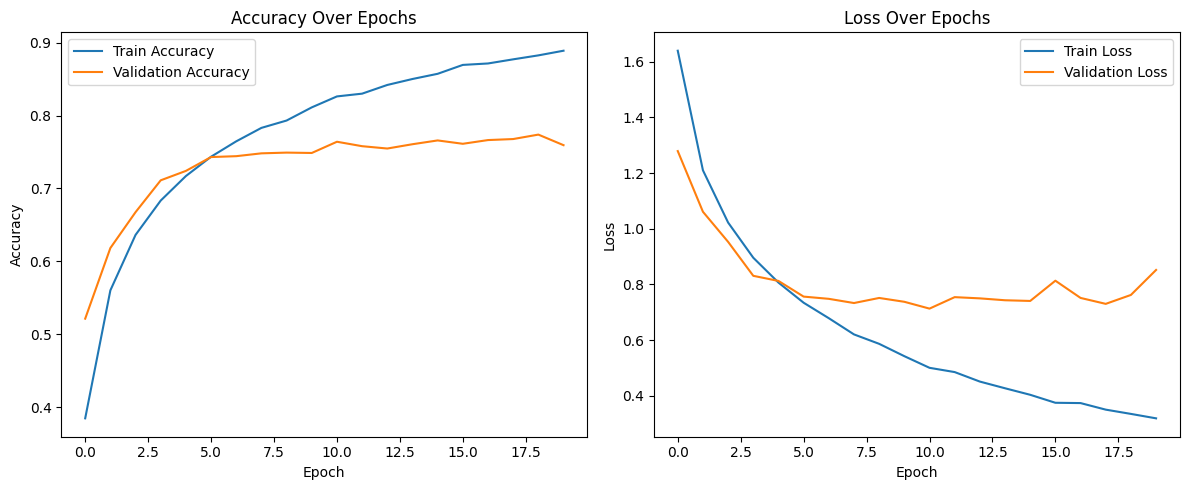

In [24]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
print("Evaluating AlexNetMini Model:")
alexnet_preds, alexnet_labels = evaluate_model(alexnet_model, test_loader, name="AlexNetMini")

Evaluating AlexNetMini Model:
🔍 AlexNetMini | Accuracy: 0.7470 | Macro F1: 0.7507
              precision    recall  f1-score   support

    airplane       0.80      0.78      0.79      1000
  automobile       0.90      0.84      0.87      1000
        bird       0.75      0.60      0.67      1000
         cat       0.49      0.61      0.54      1000
        deer       0.77      0.65      0.70      1000
         dog       0.57      0.78      0.66      1000
        frog       0.92      0.68      0.78      1000
       horse       0.81      0.80      0.80      1000
        ship       0.86      0.86      0.86      1000
       truck       0.80      0.88      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.77      0.75      0.75     10000
weighted avg       0.77      0.75      0.75     10000



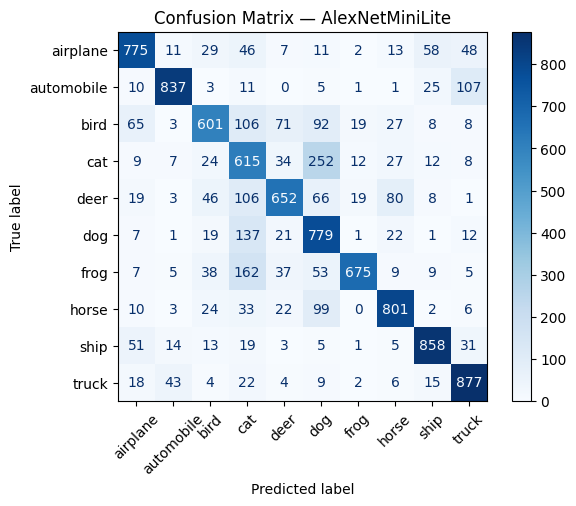

In [28]:
cm_alexnet = confusion_matrix(alexnet_labels, alexnet_preds)
disp_alexnet = ConfusionMatrixDisplay(confusion_matrix=cm_alexnet, display_labels=class_names)
disp_alexnet.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — AlexNetMiniLite")
plt.grid(False)
plt.show()

# **AlexNetMiniLite Training**

While AlexNetMini is powerful, training it on CIFAR-10 can be time-consuming, especially on limited hardware.

So, let’s define a Lite version that:
-    Trains faster
-    Uses fewer filters and fewer fully connected neurons
-    Still improves over LeNet — just not as much as full AlexNetMini

>**Architecture Summary**
```text
Input: 3×32×32 image
↓
Conv1: 3 → 32 filters, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Conv2: 32 → 64 filters, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Conv3: 64 → 128 filters, 3×3 kernel → ReLU → MaxPool (2×2)
↓
Flatten
↓
Dense (2048 → 256) → ReLU
↓
Output Layer (256 → 10)
```

>**AlexNetMiniLite Shape Transformation**

| Layer     | Input Shape   | Output Shape   | Notes                              |
|-----------|---------------|----------------|------------------------------------|
| Input     | `3×32×32`     | —              | CIFAR-10 RGB image                 |
| Conv1     | `3×32×32`     | `32×32×32`     | 32 filters, 3×3 kernel, padding=1  |
| MaxPool1  | `32×32×32`    | `32×16×16`     | 2×2 pooling, stride=2              |
| Conv2     | `32×16×16`    | `64×16×16`     | 64 filters, 3×3 kernel, padding=1  |
| MaxPool2  | `64×16×16`    | `64×8×8`       | 2×2 pooling, stride=2              |
| Conv3     | `64×8×8`      | `128×8×8`      | 128 filters, 3×3 kernel, padding=1 |
| MaxPool3  | `128×8×8`     | `128×4×4`      | 2×2 pooling, stride=2              |
| Flatten   | `128×4×4`     | `2048`         | Flattened vector (128×4×4)         |
| FC1       | `2048`        | `256`          | Fully connected + ReLU             |
| Output    | `256`         | `10`           | Final logits (10 classes)          |

</br>

This architecture:
-    Uses 3 convolutional layers with increasing filter depths (32 → 64 → 128).
-    Applies MaxPooling after each convolution to reduce spatial dimensions.
-    Ends with one hidden dense layer before the output logits.
-    Has much fewer parameters than full AlexNetMini, making it faster to train.

> Parameter Count Comparison

| Model           | Approx. Parameters | Notes                          |
|-----------------|--------------------|--------------------------------|
| MLP             | ~393,000           | Fully connected only           |
| LeNet (CIFAR-10)| ~61,000            | Very small and fast            |
| AlexNetMini     | ~2.5 million       | Deeper, heavier CNN            |
| AlexNetMiniLite | ~300,000           | Lighter, faster to train       |

</br>

> Actual counts may vary slightly based on implementation. You can use `torchsummary` or `torchinfo` to get exact values.


In [26]:
class AlexNetMiniLite(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # [B, 32, 32, 32]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # [B, 32, 16, 16]

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 16, 16]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # [B, 64, 8, 8]

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# [B, 128, 8, 8]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # [B, 128, 4, 4]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [27]:
alexnet_lite = AlexNetMiniLite().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet_lite.parameters(), lr=0.001)

# Tracking metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 20

for epoch in range(epochs):
    alexnet_lite.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = alexnet_lite(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    alexnet_lite.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = alexnet_lite(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Acc: {train_acc:.4f}, Val Acc: {val_accuracies[-1]:.4f}")


Epoch [1/20] - Train Acc: 0.4850, Val Acc: 0.5791
Epoch [2/20] - Train Acc: 0.6361, Val Acc: 0.6798
Epoch [3/20] - Train Acc: 0.6960, Val Acc: 0.7260
Epoch [4/20] - Train Acc: 0.7396, Val Acc: 0.7371
Epoch [5/20] - Train Acc: 0.7681, Val Acc: 0.7405
Epoch [6/20] - Train Acc: 0.7937, Val Acc: 0.7382
Epoch [7/20] - Train Acc: 0.8137, Val Acc: 0.7661
Epoch [8/20] - Train Acc: 0.8337, Val Acc: 0.7617
Epoch [9/20] - Train Acc: 0.8498, Val Acc: 0.7619
Epoch [10/20] - Train Acc: 0.8663, Val Acc: 0.7664
Epoch [11/20] - Train Acc: 0.8779, Val Acc: 0.7684
Epoch [12/20] - Train Acc: 0.8893, Val Acc: 0.7667
Epoch [13/20] - Train Acc: 0.8988, Val Acc: 0.7616
Epoch [14/20] - Train Acc: 0.9077, Val Acc: 0.7614
Epoch [15/20] - Train Acc: 0.9148, Val Acc: 0.7644
Epoch [16/20] - Train Acc: 0.9216, Val Acc: 0.7691
Epoch [17/20] - Train Acc: 0.9232, Val Acc: 0.7600
Epoch [18/20] - Train Acc: 0.9286, Val Acc: 0.7653
Epoch [19/20] - Train Acc: 0.9332, Val Acc: 0.7693
Epoch [20/20] - Train Acc: 0.9337, Val A

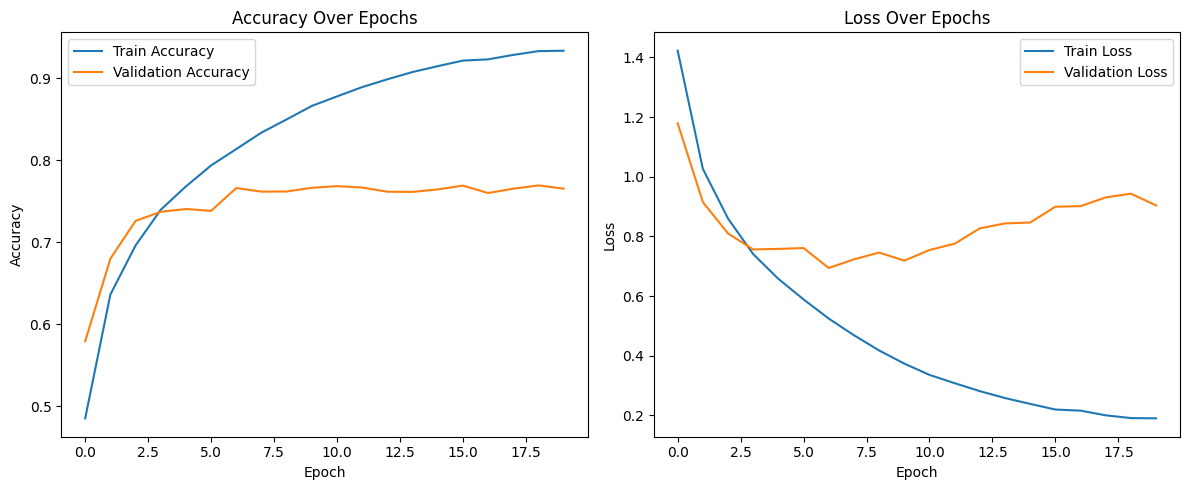

In [29]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
print("Evaluating AlexNetMiniLite Model:")
alexnet_lite_preds, alexnet_lite_labels = evaluate_model(alexnet_lite, test_loader, name="AlexNetMiniLite")

Evaluating AlexNetMiniLite Model:
🔍 AlexNetMiniLite | Accuracy: 0.7576 | Macro F1: 0.7568
              precision    recall  f1-score   support

    airplane       0.78      0.77      0.78      1000
  automobile       0.87      0.89      0.88      1000
        bird       0.70      0.61      0.66      1000
         cat       0.55      0.61      0.58      1000
        deer       0.70      0.70      0.70      1000
         dog       0.70      0.61      0.65      1000
        frog       0.76      0.86      0.81      1000
       horse       0.83      0.80      0.81      1000
        ship       0.88      0.86      0.87      1000
       truck       0.81      0.85      0.83      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



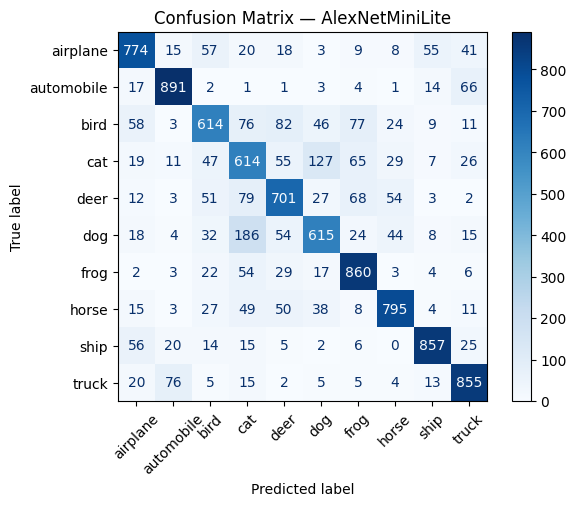

In [31]:
cm_alexnet_lite = confusion_matrix(alexnet_lite_labels, alexnet_lite_preds)
disp_alexnet_lite = ConfusionMatrixDisplay(confusion_matrix=cm_alexnet_lite, display_labels=class_names)
disp_alexnet_lite.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — AlexNetMiniLite")
plt.grid(False)
plt.show()

In [33]:
raw_data = """Model | Accuracy | Macro F1
MLP | 0.4251 | 0.4111
LeNet | 0.6137 | 0.6077
AlexNetMini | 0.7470 | 0.7507
AlexNetMiniLite | 0.7576 | 0.7568"""

df_results = pd.read_csv(io.StringIO(raw_data), sep='|')
df_results.columns = df_results.columns.str.strip() # Clean column names
df_results['Model'] = df_results['Model'].str.strip() # Clean model names

# Display the DataFrame
print("--- df_results ---")
print(df_results)

--- df_results ---
             Model  Accuracy  Macro F1
0              MLP    0.4251    0.4111
1            LeNet    0.6137    0.6077
2      AlexNetMini    0.7470    0.7507
3  AlexNetMiniLite    0.7576    0.7568


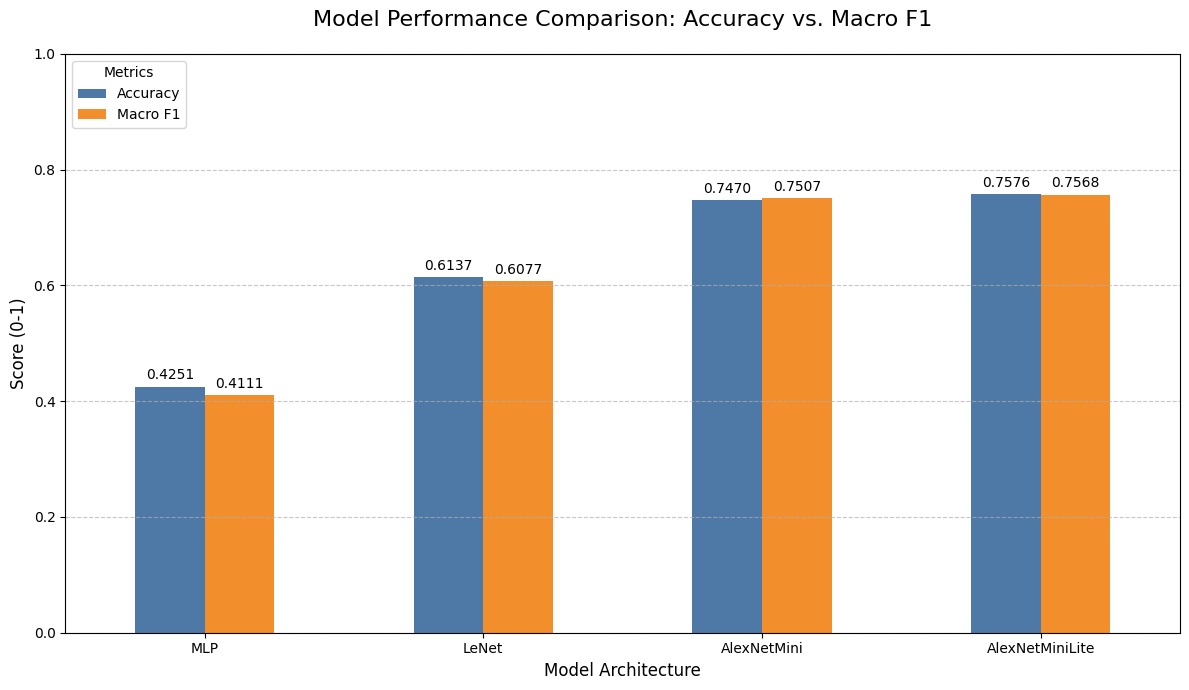

In [34]:
ax = df_results.set_index('Model').plot(
    kind='bar',
    figsize=(12, 7),
    rot=0,
    color=['#4e79a7', '#f28e2b']
)

plt.title('Model Performance Comparison: Accuracy vs. Macro F1', fontsize=16, pad=20)
plt.ylabel('Score (0-1)', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metrics', frameon=True, loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

In [35]:
torch.save(alexnet_lite.state_dict(), "alexnet_lite_cifar10.pth")